# Post-Reopening Performance of Leading Tehran Stock Exchange Stocks
### A risk–return analysis of 5 top stocks from 5 major industries vs. the equal-weighted index



This project analyzes how 5 leading stocks, one from each of 5 major industries, performed after the Tehran Stock Exchange reopened following the war (from 1405-02-29 to 1405-07-12). Each stock is compared with the equal-weighted index (EWI) in terms of return, volatility and maximum drawdown.

**Tools:** Python, pandas, NumPy, Matplotlib, finpy_tse

## 1. Data Collection
Adjusted closing prices of the five stocks and the equal-weighted index are downloaded with `finpy_tse` and combined into one DataFrame.

In [1]:
import numpy as np 
import pandas as pd 
import finpy_tse as fpy
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
# in this cell I extract the stocks data and create a data frame

stocks = ['فملی' , 'شپنا' , 'فارس' ,'صبا' , 'دعبید']
prices = {}
for s in stocks :
    prices[s] = fpy.Get_Price_History( stock = s, start_date ='1405-02-29' , end_date ='1405-07-12' , adjust_price = True  )

df = pd.DataFrame()
for s in stocks :
    df[s] = prices[s]['Adj Close']


In [3]:
# in this  cell I extract the equally weighted index data 

EWI = fpy.Get_EWI_History( start_date = '1405-02-29' , end_date = '1405-07-12' )

In [4]:
df['هم وزن'] = EWI['Adj Close']

In [5]:
#saving the data in the computer

df.to_excel('Data.xlsx')
df.to_csv('Data.csv')

## Metrics Used

| Metric | Meaning |
|---|---|
| Total Return | Last price / first price − 1 |
| Average Daily Return | Mean of daily percentage changes |
| Standard Deviation | Volatility of daily returns (risk) |
| Maximum Drawdown | Worst fall from a previous peak |
| Excess Return vs EWI | Stock's total return minus the index's total return |

## 2. Returns and Volatility

In [6]:
#daily return of each asset

returns = df.pct_change()

In [7]:
# calculating average daily return of each asset

mean = returns.mean()
((mean*100).round(2)).to_frame('Average Daily Returns %')

,Average Daily Returns %
فملی,1.28
شپنا,1.35
فارس,0.60
صبا,1.45
دعبید,1.56
هم وزن,0.94


In [8]:
# calculating standard deviation of each asset

std_dev = returns.std()
((std_dev*100).round(2)).to_frame('Standard Deviation %')

,Standard Deviation %
فملی,2.33
شپنا,2.55
فارس,2.62
صبا,2.44
دعبید,2.18
هم وزن,1.61


In [9]:
#calculating total return of each asset

total_returns = {}

for s in df.columns:
    p = df[s].dropna()                       # حذف روزهایی که قیمت ندارد
    total_returns[s] = p.iloc[-1] / p.iloc[0] - 1

total_returns = pd.Series(total_returns)     # تبدیل به سری پانداس


In [10]:
# calculating the excess return 

EWI_total_return = total_returns['هم وزن']
excess_returns = total_returns - EWI_total_return

## 3. Maximum Drawdown
$$Drawdown_t = \frac{V_t}{Peak_t} - 1$$

where $V_t$ is the price on day *t* and $Peak_t$ is the highest price reached up to that day. The maximum drawdown is the lowest (most negative) value over the whole period:

$$MDD = \min(Drawdown_t)$$

In [11]:
# calculating maximum drawdown of each asset

drawdown = df / df.cummax() - 1
max_drawdown = drawdown.min()


## 4. Cumulative Growth

The chart shows how 100 units invested in each asset at the start of the period would have grown. It makes it easy to compare the stocks with each other and with the equal-weighted index (EWI).

Note that Fars starts later than the others because it was closed after the market reopened, so its line begins from the first day it traded.

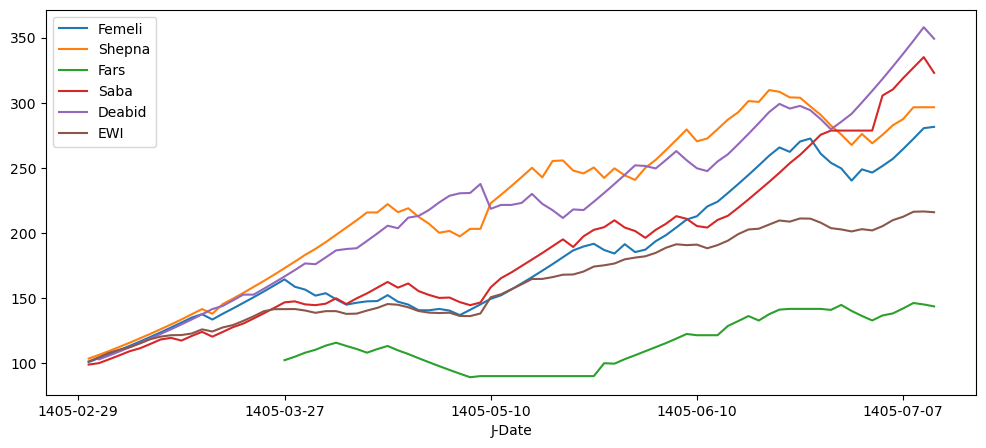

In [12]:
# if we had invested 100$ in each asset , how much would we have ?

cumulative = (1 + returns).cumprod() * 100 #$

ax1 = cumulative.plot( figsize = (12,5))
ax1.legend(['Femeli','Shepna','Fars','Saba','Deabid','EWI'])

In [13]:
summary = pd.DataFrame({
    'Total Return %': (total_returns * 100).round(2),
    'Max Drawdown %': (max_drawdown * 100).round(2),
    'Excess Return vs EWI %' : (excess_returns * 100).round(2),
    'Average  Daily Return %': (mean * 100).round(2),
    'Standard Deviation %':(std_dev * 100).round(2)    
})
summary

,Total Return %,Max Drawdown %,Excess Return vs EWI %,Average Daily Return %,Standard Deviation %
فملی,181.52,-16.69,65.56,1.28,2.33
شپنا,196.58,-13.61,80.62,1.35,2.55
فارس,43.66,-22.89,-72.30,0.60,2.62
صبا,222.98,-10.98,107.02,1.45,2.44
دعبید,249.23,-10.98,133.26,1.56,2.18
هم وزن,115.96,-6.38,0.00,0.94,1.61


## 5. Summary and Conclusions

### Key findings

- **All five stocks and the index finished the period with positive returns.** The equal-weighted index grew by about 116%.
- **Four of the five stocks beat the index.** Deabid (+249%) and Saba (+222%) delivered the highest total returns, followed by Shepna (+196%) and Fameli (+181%).
- **Fars was the exception.** It returned only about 43%, well below the index. Note that Fars was closed for part of the period, so its return is measured from the first day it traded again and is not directly comparable with the others.
- **Higher returns did not require higher drawdowns.** Deabid and Saba had the best returns and also the mildest drawdowns among the stocks (about -11%), while Fars had the deepest drawdown (about -23%) together with the weakest return.
- **The index was the safest asset.** Its maximum drawdown was only about -6%, which shows the diversification effect: holding all stocks together smooths out the big falls of individual stocks.

### Limitations

- The period is short, and the sample is only five stocks, so the results should not be generalized to the whole market.
- The stocks were chosen as leaders of their industries, which may introduce selection bias.
- All returns are nominal (in rials). In a high-inflation environment, part of these gains reflects **rising prices rather than real growth in value**.
- Past performance after a reopening does not predict future performance.

### Conclusion

After the reopening, most leading stocks strongly outperformed the equal-weighted index, with Deabid and Saba standing out on both return and drawdown. However, individual stocks carried more risk than the index, and Fars shows that being a leader in a major industry does not guarantee strong performance.